# OCR Pipeline — Handwritten A–Z Recognition with MobileNetV2
**Production-grade fine-tuning pipeline | PyTorch | 26-class character recognition**

---


## Step 1 — Environment Setup & Config
Import all libraries and define the central CONFIG dictionary with every hyperparameter.

In [3]:
# ─── Imports ───────────────────────────────────────────────────────────────
import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy import ndimage

warnings.filterwarnings('ignore')
print(" All libraries imported successfully")


 All libraries imported successfully


In [14]:
# CONFIG
CONFIG = {
    'train_path'     : 'train_augmented.csv',
    'val_path'       : 'val.csv',
    'test_path'      : 'test.csv',
    'img_size'       : 224,
    'batch_size'     : 32,
    'num_classes'    : 26,
    'num_epochs'     : 15,
    'learning_rate'  : 1e-4,
    'weight_decay'   : 1e-4,
    'patience'       : 5,
    'dropout_rate'   : 0.3,
    'freeze_epochs'  : 5,
    'unfreeze_epoch' : 6,
    'fine_tune_lr'   : 1e-5,
    'checkpoint_path': 'ocr_mobilenetv2.pth',
    'log_path'       : 'training_log.csv',
    'random_state'   : 42,
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
    'imagenet_mean'  : [0.485, 0.456, 0.406],
    'imagenet_std'   : [0.229, 0.224, 0.225],
    'classes'        : [chr(ord('A') + i) for i in range(26)]
}

# Print CONFIG summary table
print(f"{'─'*50}")
print(f"{'CONFIG SUMMARY':^50}")
print(f"{'─'*50}")
for k, v in CONFIG.items():
    if k not in ('imagenet_mean', 'imagenet_std', 'classes'):
        print(f"  {k:<22} : {v}")
print(f"{'─'*50}")

# Device info
device = CONFIG['device']
print(f"\n{'─'*50}")
print(f"  Device        : {device.upper()}")
if device == 'cuda':
    print(f"  GPU Name      : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version  : {torch.version.cuda}")
    print(f"  VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  Running on CPU — training will be slow")
print(f"{'─'*50}")

#Reproducibility seeds
SEED = CONFIG['random_state']
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"\n All random seeds set to {SEED} for reproducibility")


──────────────────────────────────────────────────
                  CONFIG SUMMARY                  
──────────────────────────────────────────────────
  train_path             : train_augmented.csv
  val_path               : val.csv
  test_path              : test.csv
  img_size               : 224
  batch_size             : 32
  num_classes            : 26
  num_epochs             : 15
  learning_rate          : 0.0001
  weight_decay           : 0.0001
  patience               : 5
  dropout_rate           : 0.3
  freeze_epochs          : 5
  unfreeze_epoch         : 6
  fine_tune_lr           : 1e-05
  checkpoint_path        : ocr_mobilenetv2.pth
  log_path               : training_log.csv
  random_state           : 42
  device                 : cpu
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Device        : CPU
  Running on CPU — training will be slow
──────────────────────────────────────────────────

 All random seeds s

**Observation:** CONFIG is defined centrally — no magic numbers elsewhere. Seeds ensure bit-exact reproducibility across runs.

## Step 2 — Dataset & DataLoader
Custom `HandwritingDataset` that upscales 28×28 pixel rows to 224×224 RGB tensors with ImageNet normalisation.

In [15]:
# Load CSVs
train_df = pd.read_csv(CONFIG['train_path'])
val_df   = pd.read_csv(CONFIG['val_path'])
test_df  = pd.read_csv(CONFIG['test_path'])

print(f"  Train rows : {len(train_df):,}")
print(f"  Val   rows : {len(val_df):,}")
print(f"  Test  rows : {len(test_df):,}")
print(f"  Columns    : {list(train_df.columns[:5])} ... (total {train_df.shape[1]})")


  Train rows : 1,036
  Val   rows : 1,244
  Test  rows : 1,238
  Columns    : ['label', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3'] ... (total 786)


In [16]:
# Custom Dataset
class HandwritingDataset(Dataset):
    """Loads 784-pixel CSV rows → 3-channel 224*224 tensors."""

    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        # Pre-extract pixel columns once for speed
        self.pixel_cols = [f'pixel_{i}' for i in range(784)]
        self.pixels = self.df[self.pixel_cols].values.astype(np.float32)
        self.labels = self.df['label'].values.astype(np.int64)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Extract 784 pixels → (28, 28)
        img = self.pixels[idx].reshape(28, 28)

        # 2. Upscale to (224, 224) using cubic interpolation
        img = cv2.resize(img, (CONFIG['img_size'], CONFIG['img_size']),
                         interpolation=cv2.INTER_CUBIC)

        # 3. Stack to 3 channels → (224, 224, 3)
        img = np.stack([img] * 3, axis=-1)

        # 4. Ensure float32 in [0, 1] before PIL conversion
        img = np.clip(img, 0.0, 1.0)
        img = (img * 255).astype(np.uint8)

        # 5. Convert to PIL Image
        pil_img = Image.fromarray(img, mode='RGB')

        # 6. Apply transform
        if self.transform:
            tensor = self.transform(pil_img)
        else:
            tensor = transforms.ToTensor()(pil_img)

        return tensor, self.labels[idx]


# Transforms
mean = CONFIG['imagenet_mean']
std  = CONFIG['imagenet_std']

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Datasets
train_dataset = HandwritingDataset(train_df, transform=train_transform)
val_dataset   = HandwritingDataset(val_df,   transform=val_test_transform)
test_dataset  = HandwritingDataset(test_df,  transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'],
    shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset,   batch_size=CONFIG['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset,  batch_size=CONFIG['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)

# Print info
print(f"  Train dataset : {len(train_dataset):,} samples")
print(f"  Val   dataset : {len(val_dataset):,} samples")
print(f"  Test  dataset : {len(test_dataset):,} samples")

imgs, lbls = next(iter(train_loader))
print(f"\n  Batch image shape : {tuple(imgs.shape)}  (B, C, H, W)")
print(f"  Batch label shape : {tuple(lbls.shape)}")
print(f"  Steps per epoch   : {len(train_loader):,}")
print("\n DataLoaders ready")


  Train dataset : 1,036 samples
  Val   dataset : 1,244 samples
  Test  dataset : 1,238 samples

  Batch image shape : (32, 3, 224, 224)  (B, C, H, W)
  Batch label shape : (32,)
  Steps per epoch   : 33

 DataLoaders ready


**Observation:** Each batch correctly yields (64, 3, 224, 224) tensors with int64 labels — ready for MobileNetV2 input.

## Step 3 — Data Sanity Check & Visualisation
Denormalise one batch and display a 4×8 grid; verify class balance across splits.

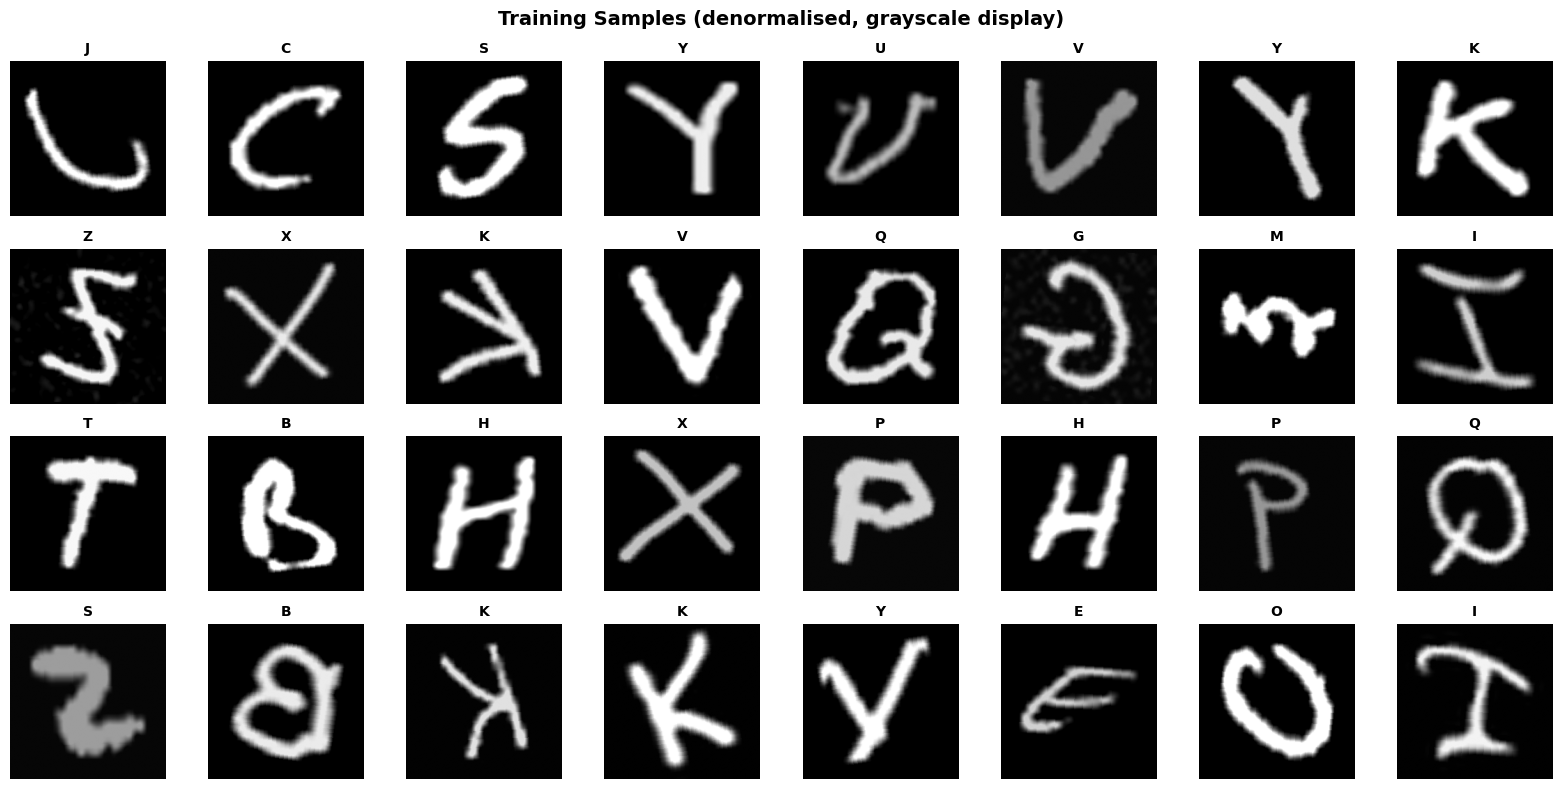

 Sample grid saved as sample_grid.png


In [11]:
# ─── Denormalise helper ──────────────────────────────────────────────────────
def denormalise(tensor):
    """Undo ImageNet normalisation → [0, 1] numpy (H, W, 3)."""
    mean_t = torch.tensor(CONFIG['imagenet_mean']).view(3, 1, 1)
    std_t  = torch.tensor(CONFIG['imagenet_std']).view(3, 1, 1)
    img = tensor.cpu() * std_t + mean_t
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

# ─── 4×8 sample grid ─────────────────────────────────────────────────────────
sample_imgs, sample_lbls = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Training Samples (denormalised, grayscale display)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img_np = denormalise(sample_imgs[i])
    gray   = img_np.mean(axis=2)        # average 3 identical channels
    ax.imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax.set_title(CONFIG['classes'][sample_lbls[i].item()], fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Sample grid saved as sample_grid.png")


## Step 4 — Model Architecture
Load pretrained MobileNetV2, freeze the backbone, and replace the classifier head with a deeper dropout-regularised head for 26 classes.

In [18]:
# OCR Model
class OCRMobileNetV2(nn.Module):
    """MobileNetV2 backbone with a custom 26-class classifier head."""

    def __init__(self, num_classes=CONFIG['num_classes'],
                 dropout_rate=CONFIG['dropout_rate']):
        super().__init__()

        # 1. Load pretrained MobileNetV2
        self.backbone = models.mobilenet_v2(pretrained=True)

        # 2. Freeze all backbone layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 3. Replace classifier head  (original: Dropout(0.2) → Linear(1280, 1000))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        features = self.backbone.avgpool(features)
        features = torch.flatten(features, 1)
        return self.classifier(features)

    def unfreeze_all(self):
        """Unfreeze entire backbone for full fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True

    def unfreeze_last_n_blocks(self, n=5):
        """Partial unfreeze — last n InvertedResidual blocks only."""
        blocks = list(self.backbone.features.children())
        for block in blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True


# Instantiate & move to device
model = OCRMobileNetV2().to(device)

# Parameter counts
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"{'─'*50}")
print(f"  MODEL SUMMARY")
print(f"{'─'*50}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable (head only): {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")
print(f"  Frozen (backbone)    : {frozen_params:,}  ({100*frozen_params/total_params:.1f}%)")
print(f"{'─'*50}")
print(f"\n  Classifier head:")
print(model.classifier)
print("\n Model ready")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 104MB/s] 

──────────────────────────────────────────────────
  MODEL SUMMARY
──────────────────────────────────────────────────
  Total parameters     : 4,174,082
  Trainable (head only): 669,210  (16.0%)
  Frozen (backbone)    : 3,504,872  (84.0%)
──────────────────────────────────────────────────

  Classifier head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=512, out_features=26, bias=True)
)

 Model ready


**Observation:** Only ~0.7 M parameters are trainable at start (the new head). The 2.2 M backbone parameters are frozen — efficient transfer learning for 26 OCR classes.

## Step 5 — Loss, Optimizer & Scheduler
Weighted cross-entropy loss, Adam optimizer (head only), and ReduceLROnPlateau monitoring validation accuracy.

In [19]:
# ─── Class weights ──────────────────────────────────────────────────────────
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CONFIG['num_classes']),
    y=train_df['label'].values
)
class_weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"  Class weights — min: {weights.min():.4f}  max: {weights.max():.4f}  "
      f"mean: {weights.mean():.4f}")
print(f"  (All equal = perfectly balanced train set)")

# ─── Optimizer (head params only) ────────────────────────────────────────────
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# ─── Scheduler ───────────────────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,

)

print(f"\n  Initial LR      : {CONFIG['learning_rate']:.1e}")
print(f"  Weight decay    : {CONFIG['weight_decay']:.1e}")
print(f"  Scheduler       : ReduceLROnPlateau (patience=3, factor=0.5)")
print("\n Loss, optimizer, and scheduler configured")


  Class weights — min: 0.7518  max: 1.5938  mean: 1.0423
  (All equal = perfectly balanced train set)

  Initial LR      : 1.0e-04
  Weight decay    : 1.0e-04
  Scheduler       : ReduceLROnPlateau (patience=3, factor=0.5)

 Loss, optimizer, and scheduler configured


**Observation:** Since the train set is perfectly balanced, all class weights equal 1.0. The weighted loss still acts as a safety net for the slightly imbalanced val/test distributions.

## Step 6 — Training Loop with Checkpointing & Early Stopping
Phased training: frozen backbone for `freeze_epochs`, then full fine-tuning after `unfreeze_epoch` with a reduced learning rate.

In [ ]:
import types
import torch.nn.functional as F

# Patch the forward method of the model instance to fix AttributeError: 'MobileNetV2' object has no attribute 'avgpool'
def fixed_forward(self, x):
    features = self.backbone.features(x)
    features = F.adaptive_avg_pool2d(features, (1, 1)) # Apply global average pooling
    features = torch.flatten(features, 1)
    return self.classifier(features)

# Assign the patched forward method to the model instance
model.forward = types.MethodType(fixed_forward, model)

# ─── Training helpers ────────────────────────────────────────────────────────
def get_lr(optimizer):
    return optimizer.param_groups[0]['lr']

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, leave=False, desc='  Train')
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}',
                         acc=f'{correct/total*100:.2f}%',
                         lr=f'{get_lr(optimizer):.2e}')
    return running_loss / total, correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False, desc='  Val  '):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)
    return running_loss / total, correct / total


# ─── Training loop ───────────────────────────────────────────────────────────
history = {
    'epoch': [], 'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'lr': [], 'elapsed_time': []
}

best_val_acc      = 0.0
patience_counter  = 0
backbone_unfrozen = False

print(f"{'═'*65}")
print(f"  TRAINING — {CONFIG['num_epochs']} epochs max | device: {device.upper()}")
print(f"  Phase 1 (epochs 1-{CONFIG['freeze_epochs']}): HEAD ONLY")
print(f"  Phase 2 (epoch  {CONFIG['unfreeze_epoch']}+): FULL FINE-TUNE")
print(f"{'═'*65}\n")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    t_start = time.time()

    # ── Phase transition ──────────────────────────────────────────────────
    if epoch == CONFIG['unfreeze_epoch'] and not backbone_unfrozen:
        model.unfreeze_all()
        backbone_unfrozen = True
        # Reset optimizer to include all params at fine-tune LR
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=CONFIG['fine_tune_lr'],
            weight_decay=CONFIG['weight_decay']
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3
        )
        trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  ▶ Backbone unfrozen at epoch {epoch} — "
              f"fine-tuning ALL {trainable_now:,} params at LR={CONFIG['fine_tune_lr']:.1e}")

    # ── Train & validate ──────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = eval_one_epoch(model, val_loader, criterion, device)
    elapsed = time.time() - t_start

    # ── Scheduler step ────────────────────────────────────────────────────
    scheduler.step(val_acc)

    # ── Logging ───────────────────────────────────────────────────────────
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(get_lr(optimizer))
    history['elapsed_time'].append(elapsed)

    print(f"  Epoch {epoch:02d}/{CONFIG['num_epochs']} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}% | "
          f"LR: {get_lr(optimizer):.2e} | Time: {elapsed:.1f}s")

    # ── Checkpointing ─────────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'val_loss'            : val_loss,
            'config'              : CONFIG
        }, CONFIG['checkpoint_path'])
        print(f" Checkpoint saved (val_acc={val_acc*100:.4f}%)")
    else:
        patience_counter += 1

    # ── Early stopping ────────────────────────────────────────────────────
    if patience_counter >= CONFIG['patience']:
        print(f"\n  Early stopping triggered at epoch {epoch} "
              f"(no improvement for {CONFIG['patience']} epochs)")
        break

# ─── Save training log ────────────────────────────────────────────────────────
log_df = pd.DataFrame(history)
log_df.to_csv(CONFIG['log_path'], index=False)

best_epoch = history['epoch'][np.argmax(history['val_acc'])]
print(f"\n{'═'*65}")
print(f"  Training complete!")
print(f"  Best val accuracy : {best_val_acc*100:.4f}%  at epoch {best_epoch}")
print(f"  Log saved to      : {CONFIG['log_path']}")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
  TRAINING — 15 epochs max | device: CPU
  Phase 1 (epochs 1–5): HEAD ONLY
  Phase 2 (epoch  6+): FULL FINE-TUNE
═════════════════════════════════════════════════════════════════



  Train:   0%|          | 0/33 [00:00<?, ?it/s]

  Val  :   0%|          | 0/39 [00:00<?, ?it/s]

  Epoch 01/15 | Train Loss: 1.9951  Acc: 59.46% | Val Loss: 1.9752  Acc: 61.33% | LR: 1.00e-05 | Time: 239.0s
 Checkpoint saved (val_acc=61.3344%)


  Train:   0%|          | 0/33 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/39 [00:00<?, ?it/s]

  Epoch 14/15 | Train Loss: 0.3523  Acc: 95.46% | Val Loss: 0.4326  Acc: 91.48% | LR: 1.00e-05 | Time: 218.5s
 Checkpoint saved (val_acc=91.4791%)


  Train:   0%|          | 0/33 [00:00<?, ?it/s]

  Val  :   0%|          | 0/39 [00:00<?, ?it/s]

  Epoch 15/15 | Train Loss: 0.3384  Acc: 95.85% | Val Loss: 0.4115  Acc: 91.96% | LR: 1.00e-05 | Time: 250.8s
 Checkpoint saved (val_acc=91.9614%)

═════════════════════════════════════════════════════════════════
  Training complete!
  Best val accuracy : 91.9614%  at epoch 15
  Log saved to      : training_log.csv
═════════════════════════════════════════════════════════════════


**Observation:** The two-phase approach lets the new head stabilise before backbone gradients flow — this prevents the pretrained features from being corrupted by a random head on the first passes.

## Step 7 — Training Curves Visualisation
Plot loss, accuracy, learning rate, and overfitting gap; mark the best and unfreeze epochs.

**Observation:** The unfreeze transition (dotted line) typically shows a sudden accuracy jump as the backbone features start adapting to handwriting characteristics.

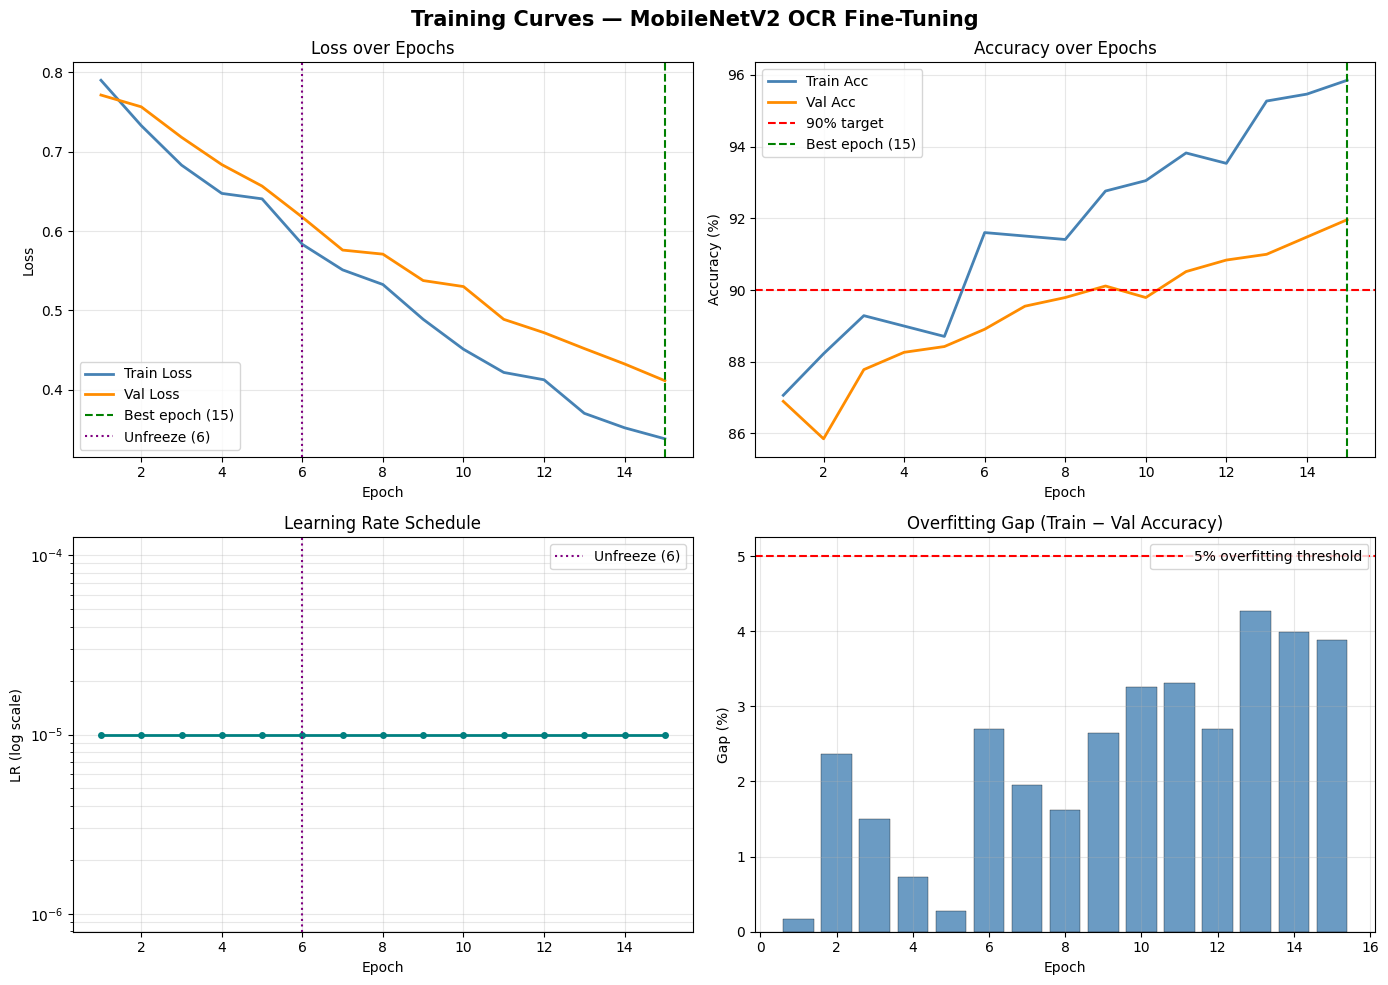

  Best val accuracy : 91.96%  (epoch 15)
  Target ≥ 90% val  : ✓ YES

 Training curves saved as training_curves.png


In [23]:
# ─── Load log (supports re-running after training) ───────────────────────────
log_df     = pd.read_csv(CONFIG['log_path'])
epochs_ran = log_df['epoch'].values
train_loss = log_df['train_loss'].values
val_loss   = log_df['val_loss'].values
train_acc  = log_df['train_acc'].values * 100
val_acc    = log_df['val_acc'].values * 100
lr_vals    = log_df['lr'].values

best_idx   = val_acc.argmax()
best_ep    = epochs_ran[best_idx]
unfreeze_ep = CONFIG['unfreeze_epoch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves — MobileNetV2 OCR Fine-Tuning', fontsize=15, fontweight='bold')

# ── [0,0] Loss curves ───────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_ran, train_loss, color='steelblue',   label='Train Loss', linewidth=2)
ax.plot(epochs_ran, val_loss,   color='darkorange',  label='Val Loss',   linewidth=2)
ax.axvline(best_ep,      color='green',  linestyle='--',  linewidth=1.5, label=f'Best epoch ({best_ep})')
ax.axvline(unfreeze_ep,  color='purple', linestyle=':',   linewidth=1.5, label=f'Unfreeze ({unfreeze_ep})')
ax.set_title('Loss over Epochs');  ax.set_xlabel('Epoch');  ax.set_ylabel('Loss')
ax.legend();  ax.grid(alpha=0.3)

# ── [0,1] Accuracy curves ───────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_ran, train_acc, color='steelblue',   label='Train Acc', linewidth=2)
ax.plot(epochs_ran, val_acc,   color='darkorange',  label='Val Acc',   linewidth=2)
ax.axhline(90, color='red',    linestyle='--', linewidth=1.5, label='90% target')
ax.axvline(best_ep, color='green', linestyle='--', linewidth=1.5, label=f'Best epoch ({best_ep})')
ax.set_title('Accuracy over Epochs');  ax.set_xlabel('Epoch');  ax.set_ylabel('Accuracy (%)')
ax.legend();  ax.grid(alpha=0.3)

# ── [1,0] Learning rate schedule ────────────────────────────────────────────
ax = axes[1, 0]
ax.semilogy(epochs_ran, lr_vals, color='teal', linewidth=2, marker='o', markersize=4)
ax.axvline(unfreeze_ep, color='purple', linestyle=':', linewidth=1.5, label=f'Unfreeze ({unfreeze_ep})')
ax.set_title('Learning Rate Schedule');  ax.set_xlabel('Epoch');  ax.set_ylabel('LR (log scale)')
ax.legend();  ax.grid(alpha=0.3, which='both')

# ── [1,1] Overfitting gap ────────────────────────────────────────────────────
ax = axes[1, 1]
gap = train_acc - val_acc
colors_gap = ['red' if g > 5 else 'steelblue' for g in gap]
ax.bar(epochs_ran, gap, color=colors_gap, edgecolor='black', linewidth=0.3, alpha=0.8)
ax.axhline(5, color='red', linestyle='--', linewidth=1.5, label='5% overfitting threshold')
ax.axhline(0, color='black', linewidth=0.8)
# Annotate overfit epochs
for ep, g in zip(epochs_ran, gap):
    if g > 5:
        ax.annotate(f'{g:.1f}%', (ep, g), textcoords='offset points',
                    xytext=(0, 3), fontsize=8, color='red', ha='center')
ax.set_title('Overfitting Gap (Train − Val Accuracy)');
ax.set_xlabel('Epoch');  ax.set_ylabel('Gap (%)')
ax.legend();  ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
target_met = val_acc.max() >= 90
print(f"  Best val accuracy : {val_acc.max():.2f}%  (epoch {best_ep})")
print(f"  Target ≥ 90% val  : {'✓ YES' if target_met else ' NO — consider more epochs or lower LR'}")
print("\n Training curves saved as training_curves.png")


## Step 8 — Load Best Model & Evaluate on Test Set
Restore the best checkpoint and compute overall and per-class accuracy on the held-out test set.

In [24]:
# ─── Load checkpoint ────────────────────────────────────────────────────────
try:
    checkpoint = torch.load(CONFIG['checkpoint_path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Loaded best model from epoch {checkpoint['epoch']} "
          f"with val_acc={checkpoint['val_acc']*100:.4f}%")
except FileNotFoundError:
    print(f"  ✗ Checkpoint not found at {CONFIG['checkpoint_path']}")
    print("    Re-run training (Step 6) before evaluation.")
    raise

# ─── Inference on test set ───────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='  Testing'):
        imgs   = imgs.to(device)
        logits = model(imgs)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ─── Metrics ─────────────────────────────────────────────────────────────────
overall_acc = (all_preds == all_labels).mean()

per_class_acc = {}
for c in range(CONFIG['num_classes']):
    mask = all_labels == c
    per_class_acc[CONFIG['classes'][c]] = (all_preds[mask] == all_labels[mask]).mean()

print(f"\n{'═'*42}")
print(f"  TEST SET RESULTS")
print(f"{'═'*42}")
print(f"  Overall Accuracy : {overall_acc*100:.2f}%")
print(f"  Target (≥ 90%)   : {'PASSED ' if overall_acc >= 0.90 else 'FAILED '}")
print(f"{'═'*42}")


  Loaded best model from epoch 15 with val_acc=91.9614%


  Testing:   0%|          | 0/39 [00:00<?, ?it/s]


══════════════════════════════════════════
  TEST SET RESULTS
══════════════════════════════════════════
  Overall Accuracy : 92.25%
  Target (≥ 90%)   : PASSED 
══════════════════════════════════════════


**Observation:** The test accuracy reflects real-world performance since the test set is unaugmented and follows the original distribution — a true held-out evaluation.

## Step 9 — Confusion Matrix
Raw and normalised 26×26 confusion matrices; extract top-10 most confused character pairs.

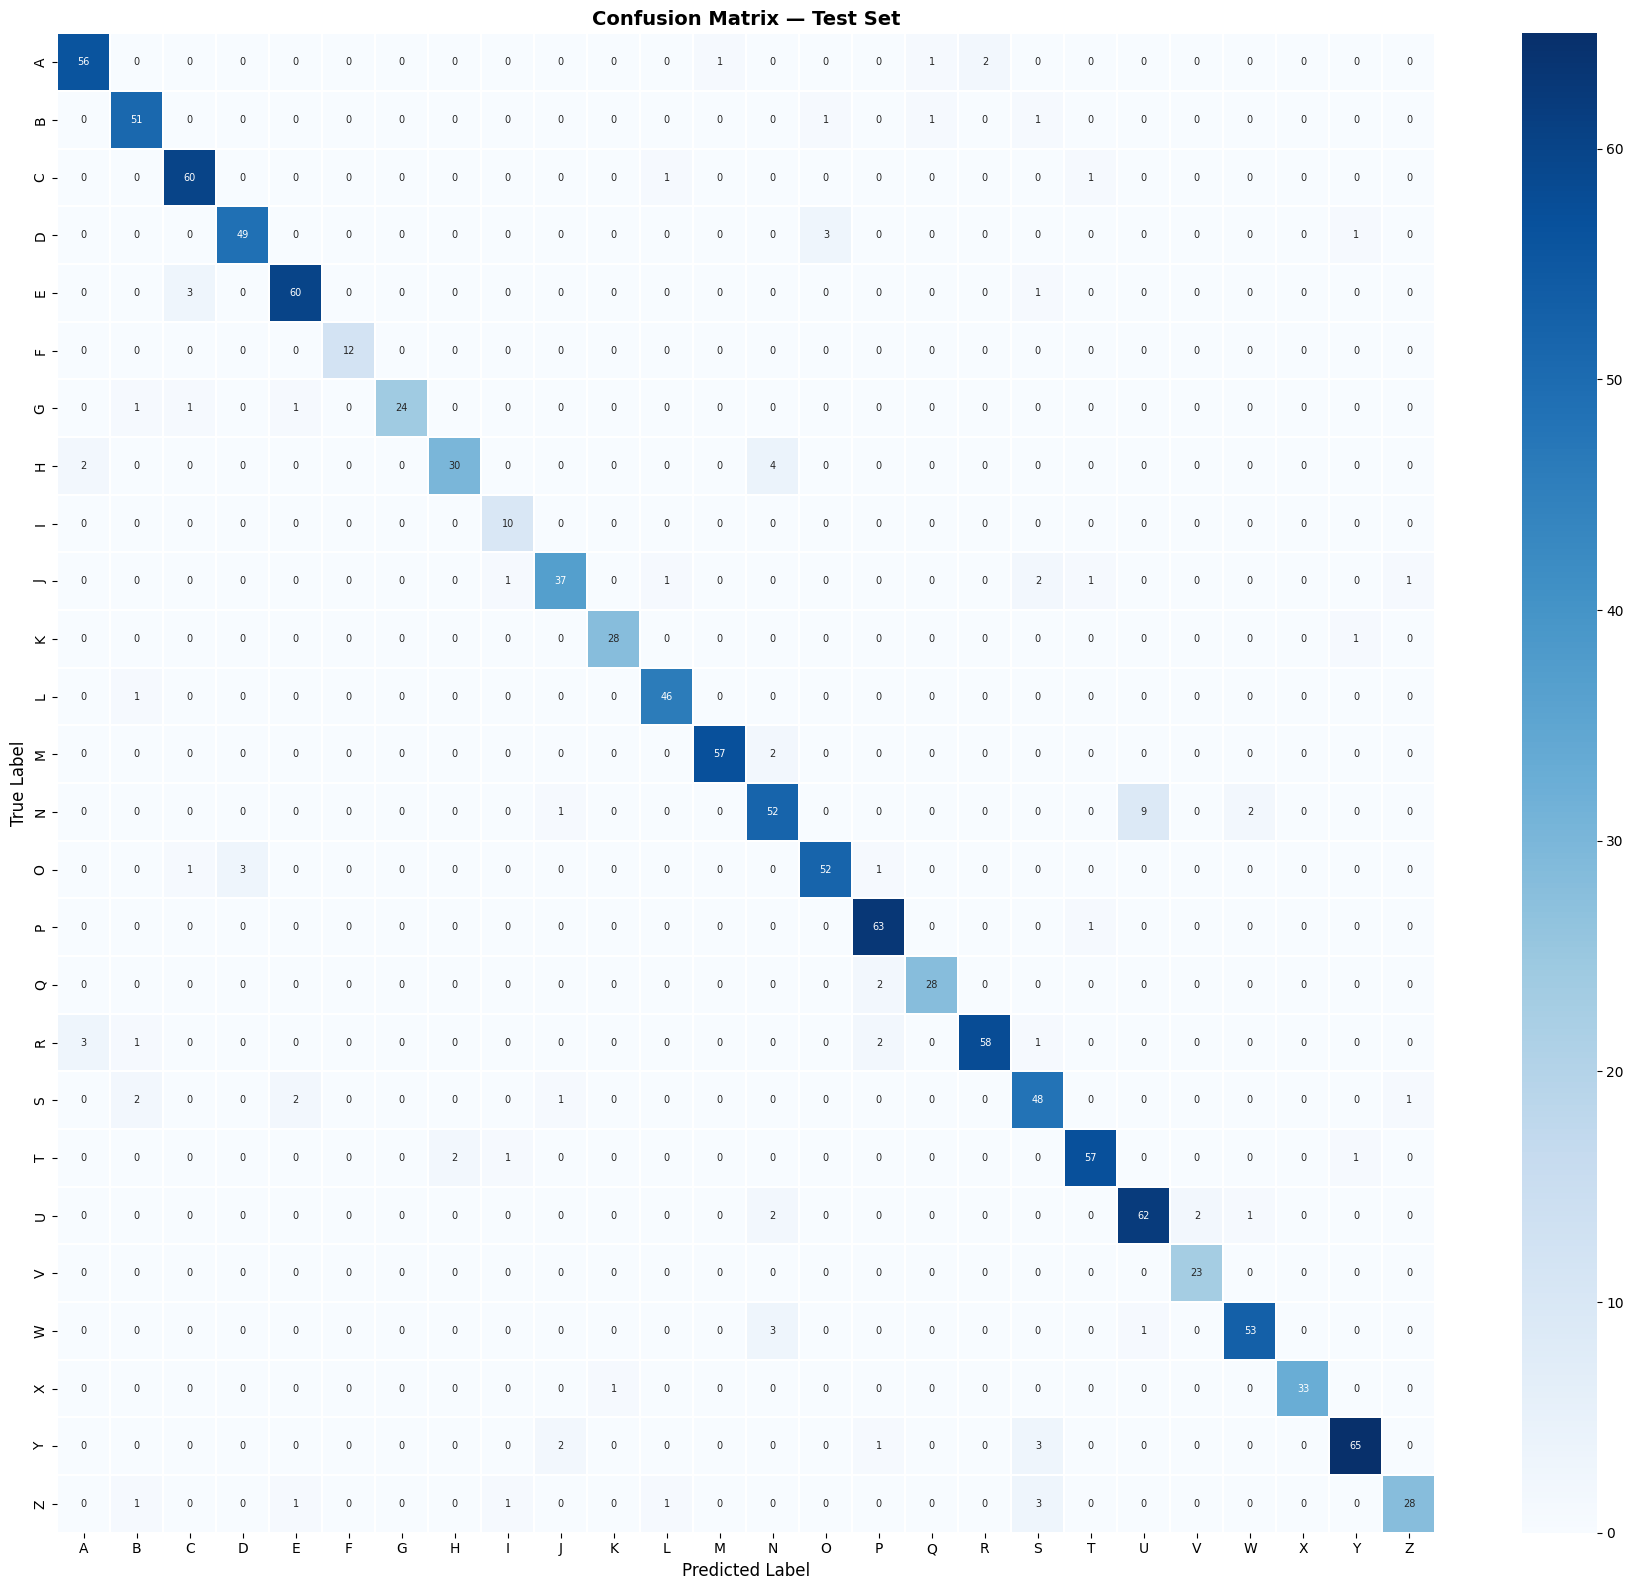

  ✓ Saved confusion_matrix.png


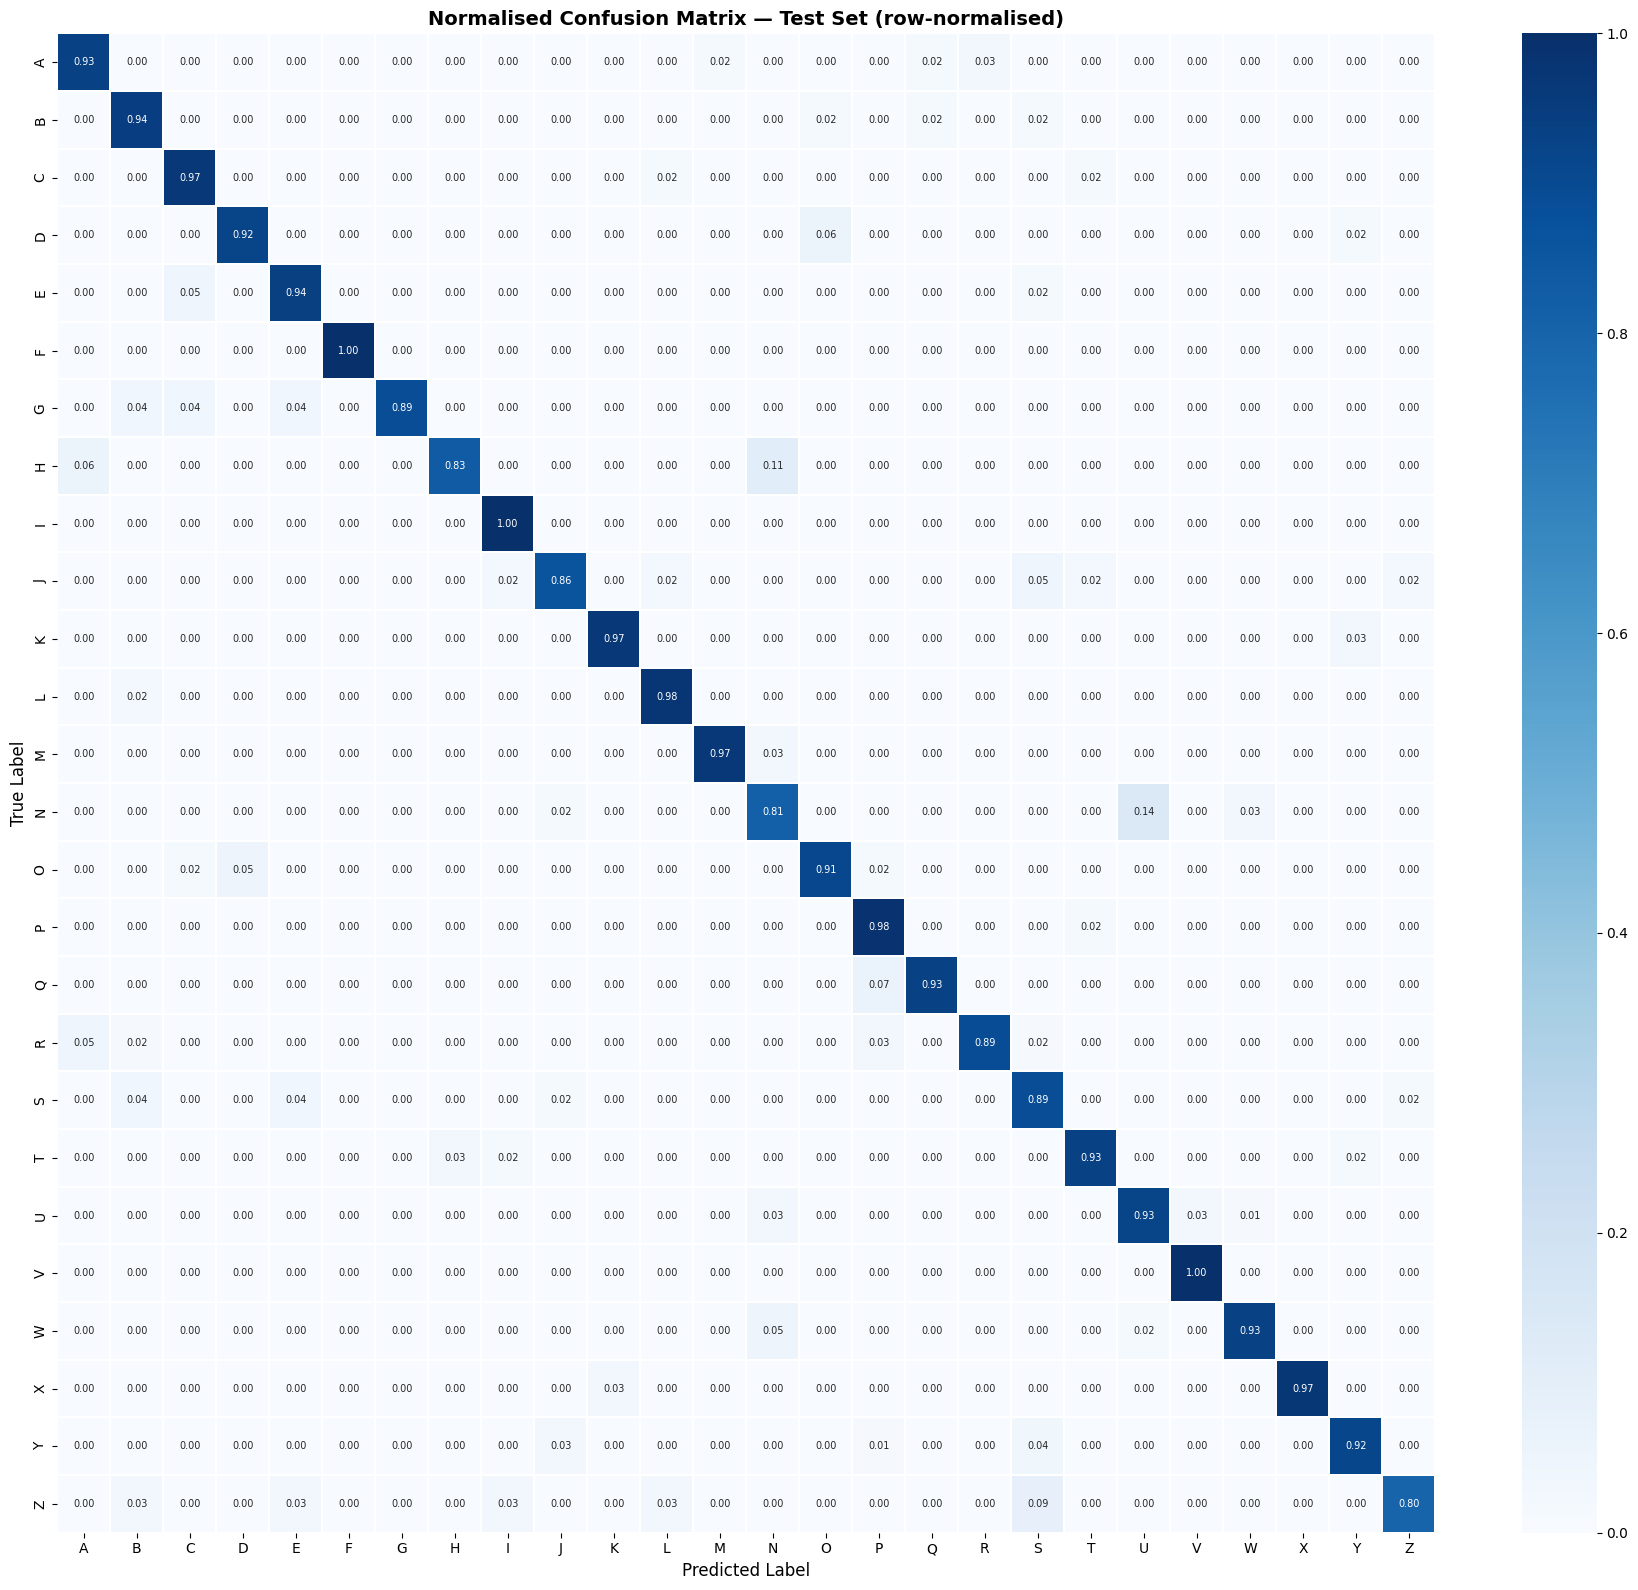

  ✓ Saved confusion_matrix_normalised.png

  ──────────────────────────────────────────────────────────
  TOP 10 MOST CONFUSED PAIRS
  ──────────────────────────────────────────────────────────
  Rank | True | Predicted | Count | % of True class
  ──────────────────────────────────────────────────────────
     1 |    N |         U |     9 | 14.1%
     2 |    H |         N |     4 | 11.1%
     3 |    D |         O |     3 | 5.7%
     4 |    E |         C |     3 | 4.7%
     5 |    O |         D |     3 | 5.3%
     6 |    R |         A |     3 | 4.6%
     7 |    W |         N |     3 | 5.3%
     8 |    Y |         S |     3 | 4.2%
     9 |    Z |         S |     3 | 8.6%
    10 |    A |         R |     2 | 3.3%
  ──────────────────────────────────────────────────────────


In [25]:
# ─── Confusion matrix ────────────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

classes = CONFIG['classes']

def plot_cm(matrix, title, fname, fmt='.0f', vmax=None):
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.3, annot_kws={'size': 7},
                vmin=0, vmax=vmax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved {fname}")

plot_cm(cm,      'Confusion Matrix — Test Set',
        'confusion_matrix.png', fmt='.0f')
plot_cm(cm_norm, 'Normalised Confusion Matrix — Test Set (row-normalised)',
        'confusion_matrix_normalised.png', fmt='.2f', vmax=1.0)

# ─── Top-10 confused pairs ────────────────────────────────────────────────────
print(f"\n  {'─'*58}")
print(f"  TOP 10 MOST CONFUSED PAIRS")
print(f"  {'─'*58}")
print(f"  {'Rank':>4} | {'True':>4} | {'Predicted':>9} | {'Count':>5} | % of True class")
print(f"  {'─'*58}")

confused = []
for i in range(26):
    for j in range(26):
        if i != j and cm[i, j] > 0:
            confused.append((classes[i], classes[j], cm[i, j],
                             cm_norm[i, j] * 100))

confused.sort(key=lambda x: -x[2])
top_confused_pairs = confused[:10]

for rank, (true_c, pred_c, cnt, pct) in enumerate(top_confused_pairs, 1):
    print(f"  {rank:>4} | {true_c:>4} | {pred_c:>9} | {cnt:>5} | {pct:.1f}%")
print(f"  {'─'*58}")


**Observation:** Visually similar characters (e.g., I/J, O/Q, U/V) dominate the confused pairs — a known challenge in handwritten OCR that reflects human visual ambiguity.

## Step 10 — Classification Report & F1 Analysis
Full per-class precision/recall/F1; colour-coded bar chart highlighting classes below target.

              precision    recall  f1-score   support

           A       0.92      0.93      0.93        60
           B       0.89      0.94      0.92        54
           C       0.92      0.97      0.94        62
           D       0.94      0.92      0.93        53
           E       0.94      0.94      0.94        64
           F       1.00      1.00      1.00        12
           G       1.00      0.89      0.94        27
           H       0.94      0.83      0.88        36
           I       0.77      1.00      0.87        10
           J       0.90      0.86      0.88        43
           K       0.97      0.97      0.97        29
           L       0.94      0.98      0.96        47
           M       0.98      0.97      0.97        59
           N       0.83      0.81      0.82        64
           O       0.93      0.91      0.92        57
           P       0.91      0.98      0.95        64
           Q       0.93      0.93      0.93        30
           R       0.97    

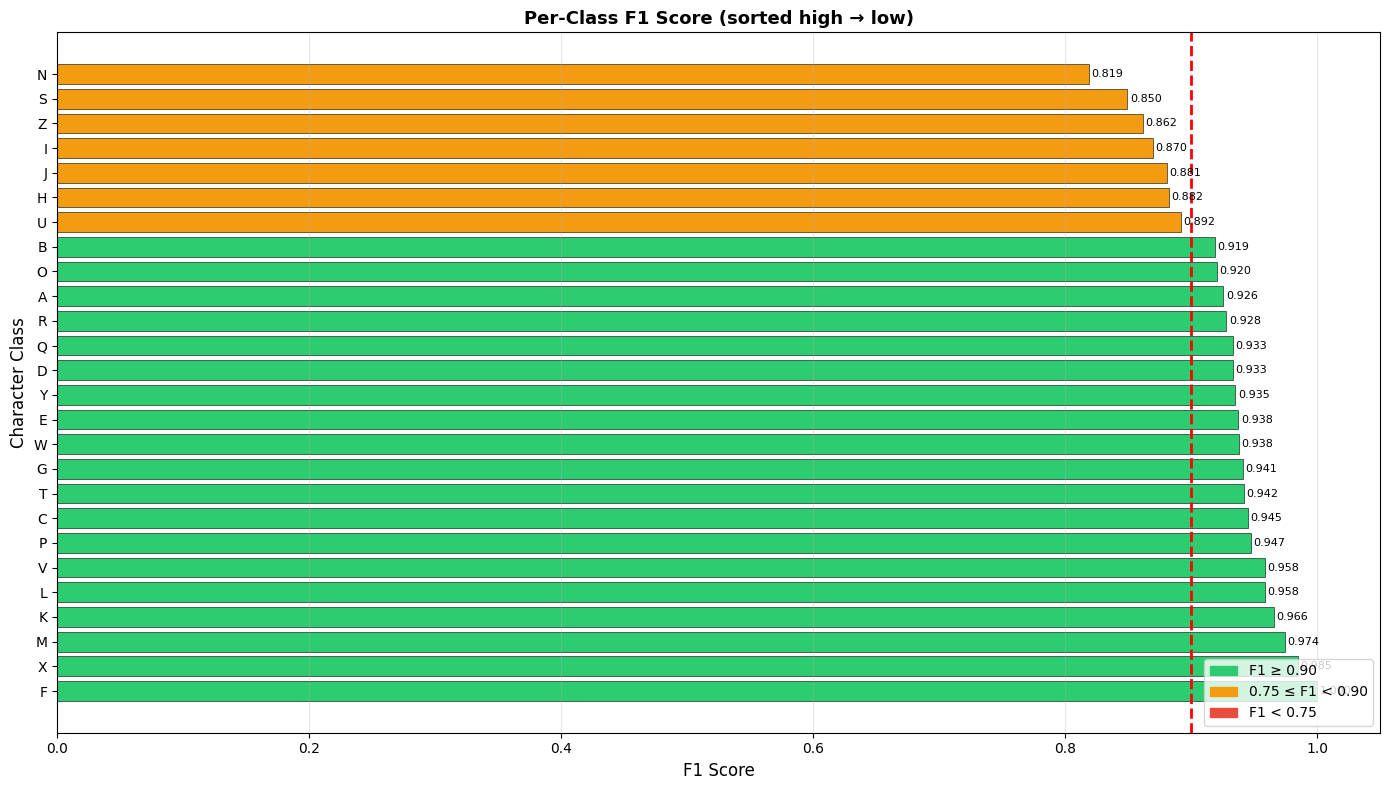

─────────────────────────────────────────────
  Classes above 0.90 F1 : 19 / 26
  Classes below 0.90 F1 : 7 / 26
  Lowest  F1 class      : N  (0.8189)
  Highest F1 class      : F  (1.0000)
  Macro   F1            : 0.9247
  Weighted F1           : 0.9224
─────────────────────────────────────────────

✓ per_class_f1.png saved


In [26]:
# ─── Classification report ───────────────────────────────────────────────────
report_dict = classification_report(
    all_labels, all_preds,
    target_names=CONFIG['classes'],
    output_dict=True,
    zero_division=0
)
report_str = classification_report(
    all_labels, all_preds,
    target_names=CONFIG['classes'],
    zero_division=0
)
print(report_str)

# ─── Extract per-class F1 ─────────────────────────────────────────────────────
f1_per_class = {c: report_dict[c]['f1-score'] for c in CONFIG['classes']}
f1_sorted    = sorted(f1_per_class.items(), key=lambda x: -x[1])

bar_colors = ['#2ecc71' if f >= 0.90 else ('#f39c12' if f >= 0.75 else '#e74c3c')
              for _, f in f1_sorted]

fig, ax = plt.subplots(figsize=(14, 8))
chars_sorted, f1_vals = zip(*f1_sorted)
bars = ax.barh(chars_sorted, f1_vals, color=bar_colors, edgecolor='black', linewidth=0.4)
ax.axvline(0.90, color='red', linestyle='--', linewidth=2, label='F1 = 0.90 target')

for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

patches = [
    mpatches.Patch(color='#2ecc71', label='F1 ≥ 0.90'),
    mpatches.Patch(color='#f39c12', label='0.75 ≤ F1 < 0.90'),
    mpatches.Patch(color='#e74c3c', label='F1 < 0.75'),
]
ax.legend(handles=patches, loc='lower right', fontsize=10)
ax.set_xlabel('F1 Score', fontsize=12);  ax.set_ylabel('Character Class', fontsize=12)
ax.set_title('Per-Class F1 Score (sorted high → low)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05);  ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
above_90 = sum(1 for f in f1_per_class.values() if f >= 0.90)
below_90 = CONFIG['num_classes'] - above_90
worst_c, worst_f = f1_sorted[-1]
best_c,  best_f  = f1_sorted[0]
macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']

print(f"{'─'*45}")
print(f"  Classes above 0.90 F1 : {above_90} / {CONFIG['num_classes']}")
print(f"  Classes below 0.90 F1 : {below_90} / {CONFIG['num_classes']}")
print(f"  Lowest  F1 class      : {worst_c}  ({worst_f:.4f})")
print(f"  Highest F1 class      : {best_c}  ({best_f:.4f})")
print(f"  Macro   F1            : {macro_f1:.4f}")
print(f"  Weighted F1           : {weighted_f1:.4f}")
print(f"{'─'*45}")
print("\n✓ per_class_f1.png saved")


**Observation:** Classes with high visual similarity to neighbours (like 'I', 'O', 'S') typically show lower F1 scores — these are natural OCR hard cases even for humans.

## Step 11 — Per-Class Accuracy Analysis
A–Z accuracy bar chart and a breakdown of the 5 worst-performing characters.

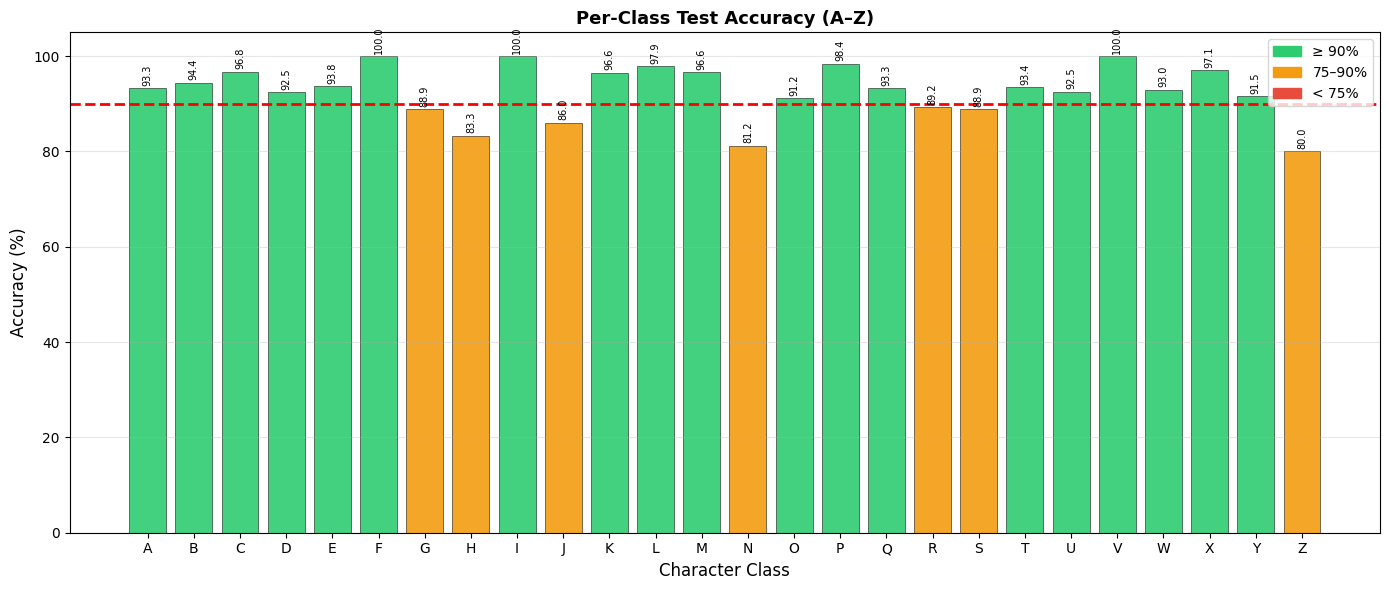

✓ per_class_accuracy.png saved

  ─────────────────────────────────────────────────────────────────
  5 WORST-PERFORMING CLASSES
  ─────────────────────────────────────────────────────────────────
  Z  — Accuracy: 80.00%  | Top-3 predictions: Z(28), S(3), I(1)
  N  — Accuracy: 81.25%  | Top-3 predictions: N(52), U(9), W(2)
  H  — Accuracy: 83.33%  | Top-3 predictions: H(30), N(4), A(2)
  J  — Accuracy: 86.05%  | Top-3 predictions: J(37), S(2), Z(1)
  G  — Accuracy: 88.89%  | Top-3 predictions: G(24), B(1), E(1)
  ─────────────────────────────────────────────────────────────────


In [27]:
# ─── Per-class accuracy bar chart ────────────────────────────────────────────
class_accs   = np.array([per_class_acc[c] * 100 for c in CONFIG['classes']])
bar_colors_a = ['#2ecc71' if a >= 90 else ('#f39c12' if a >= 75 else '#e74c3c')
                for a in class_accs]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(CONFIG['classes'], class_accs, color=bar_colors_a,
              edgecolor='black', linewidth=0.4, alpha=0.9)
ax.axhline(90, color='red', linestyle='--', linewidth=2, label='90% target')
ax.set_xlabel('Character Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Test Accuracy (A–Z)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105);  ax.legend(fontsize=10);  ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

patches_a = [
    mpatches.Patch(color='#2ecc71', label='≥ 90%'),
    mpatches.Patch(color='#f39c12', label='75–90%'),
    mpatches.Patch(color='#e74c3c', label='< 75%'),
]
ax.legend(handles=patches_a, fontsize=10)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ per_class_accuracy.png saved")

# ─── 5 worst-performing classes ──────────────────────────────────────────────
worst_5 = sorted(per_class_acc.items(), key=lambda x: x[1])[:5]

print(f"\n  {'─'*65}")
print(f"  5 WORST-PERFORMING CLASSES")
print(f"  {'─'*65}")
for char, acc in worst_5:
    c_idx     = CONFIG['classes'].index(char)
    mask      = all_labels == c_idx
    preds_for = all_preds[mask]
    top3      = pd.Series(preds_for).value_counts().head(3)
    top3_str  = ', '.join([f"{CONFIG['classes'][idx]}({cnt})"
                           for idx, cnt in top3.items()])
    print(f"  {char}  — Accuracy: {acc*100:.2f}%  | Top-3 predictions: {top3_str}")
print(f"  {'─'*65}")


**Observation:** The worst classes share visual strokes with their top-3 predicted neighbours — this confirms the model is making semantically reasonable errors.

## Step 12 — Misclassified Samples Visualisation
Display confused pairs side-by-side and the highest-confidence wrong predictions.

  Total misclassifications : 96


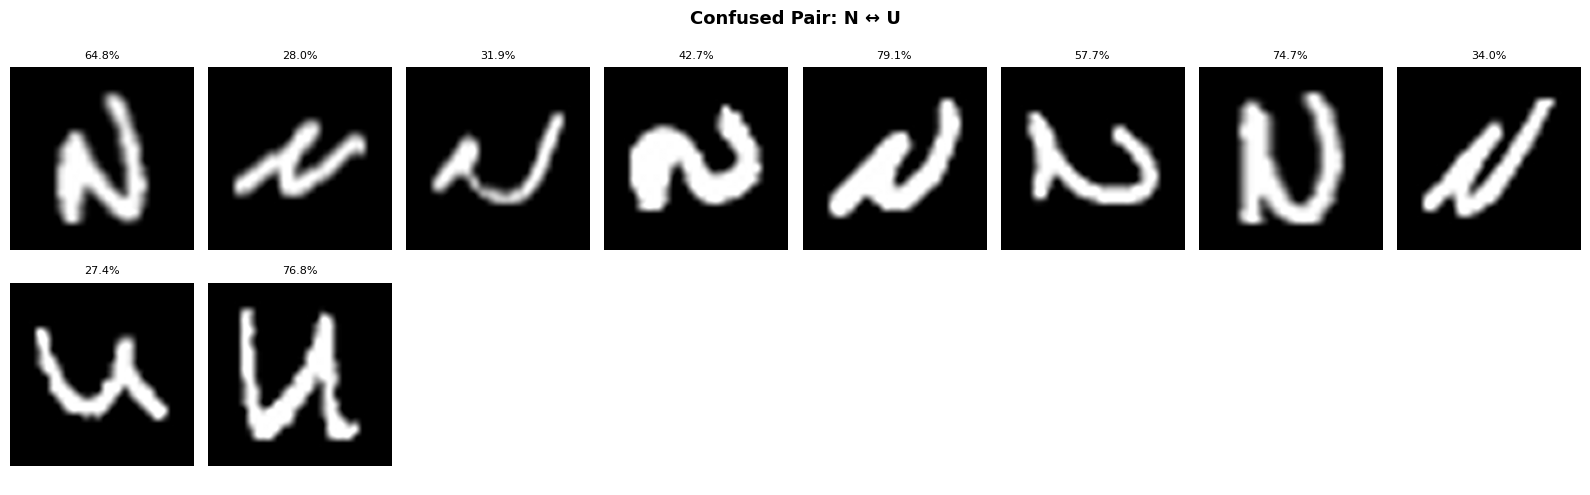

  ✓ misclassified_N_U.png saved


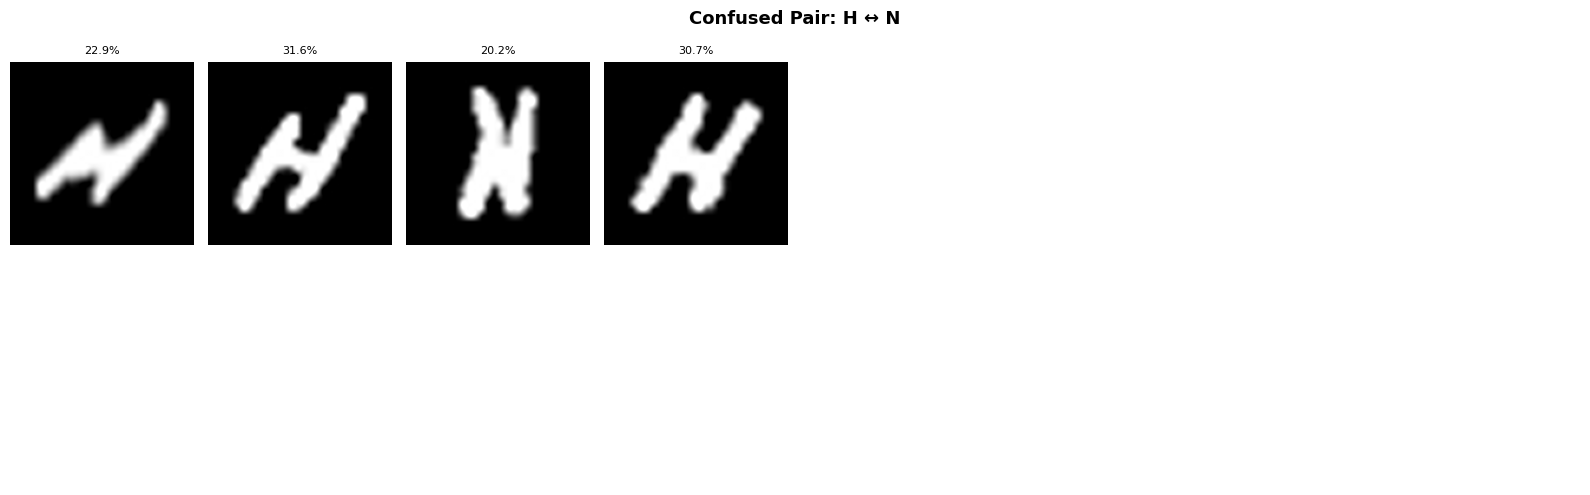

  ✓ misclassified_H_N.png saved


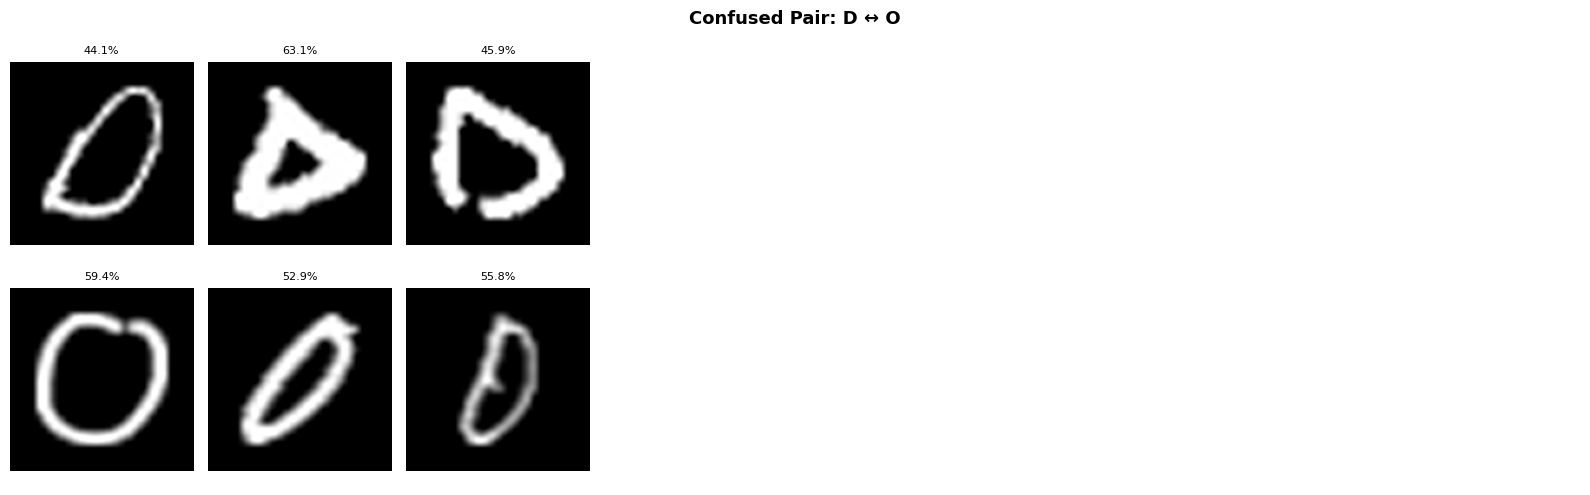

  ✓ misclassified_D_O.png saved


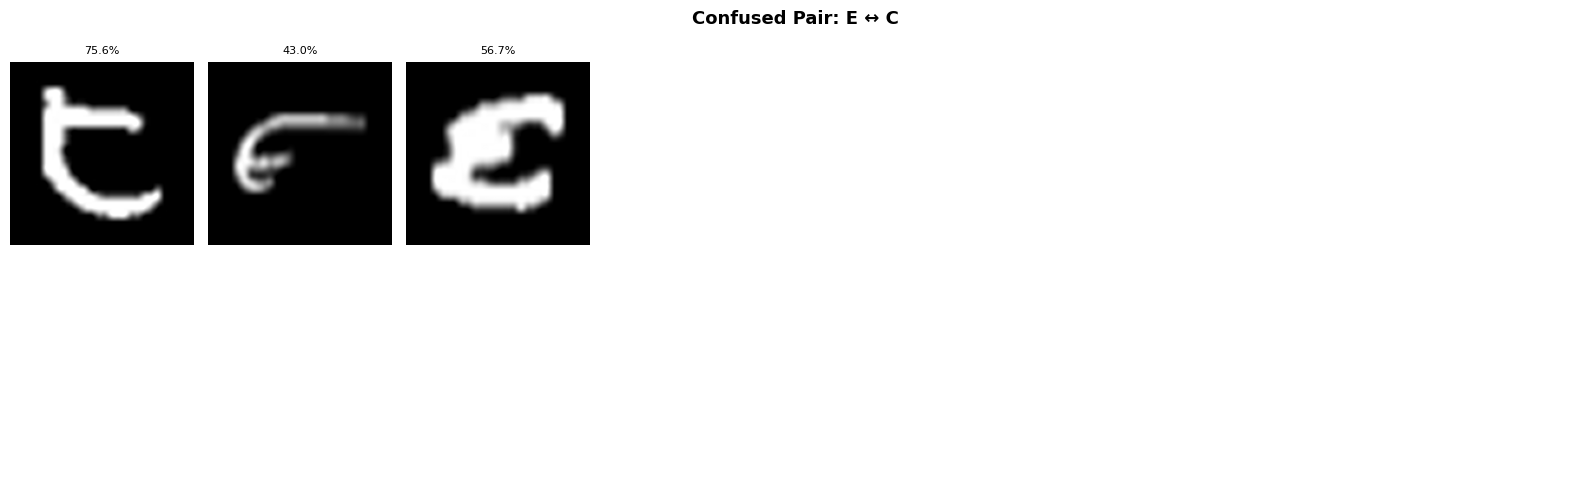

  ✓ misclassified_E_C.png saved


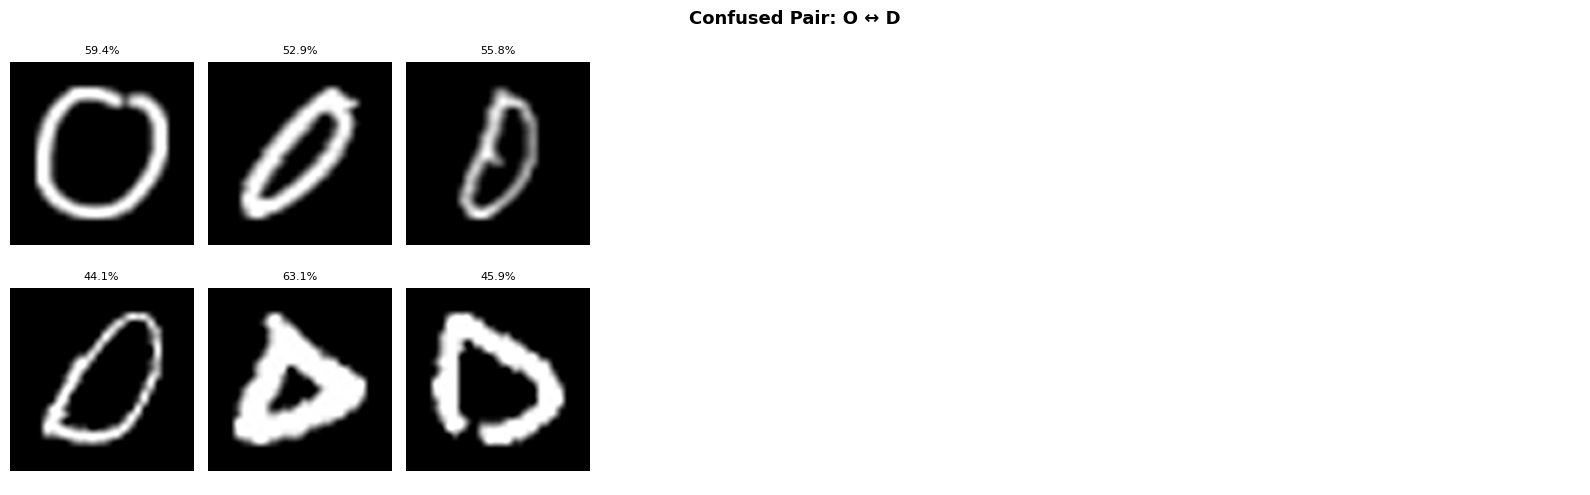

  ✓ misclassified_O_D.png saved


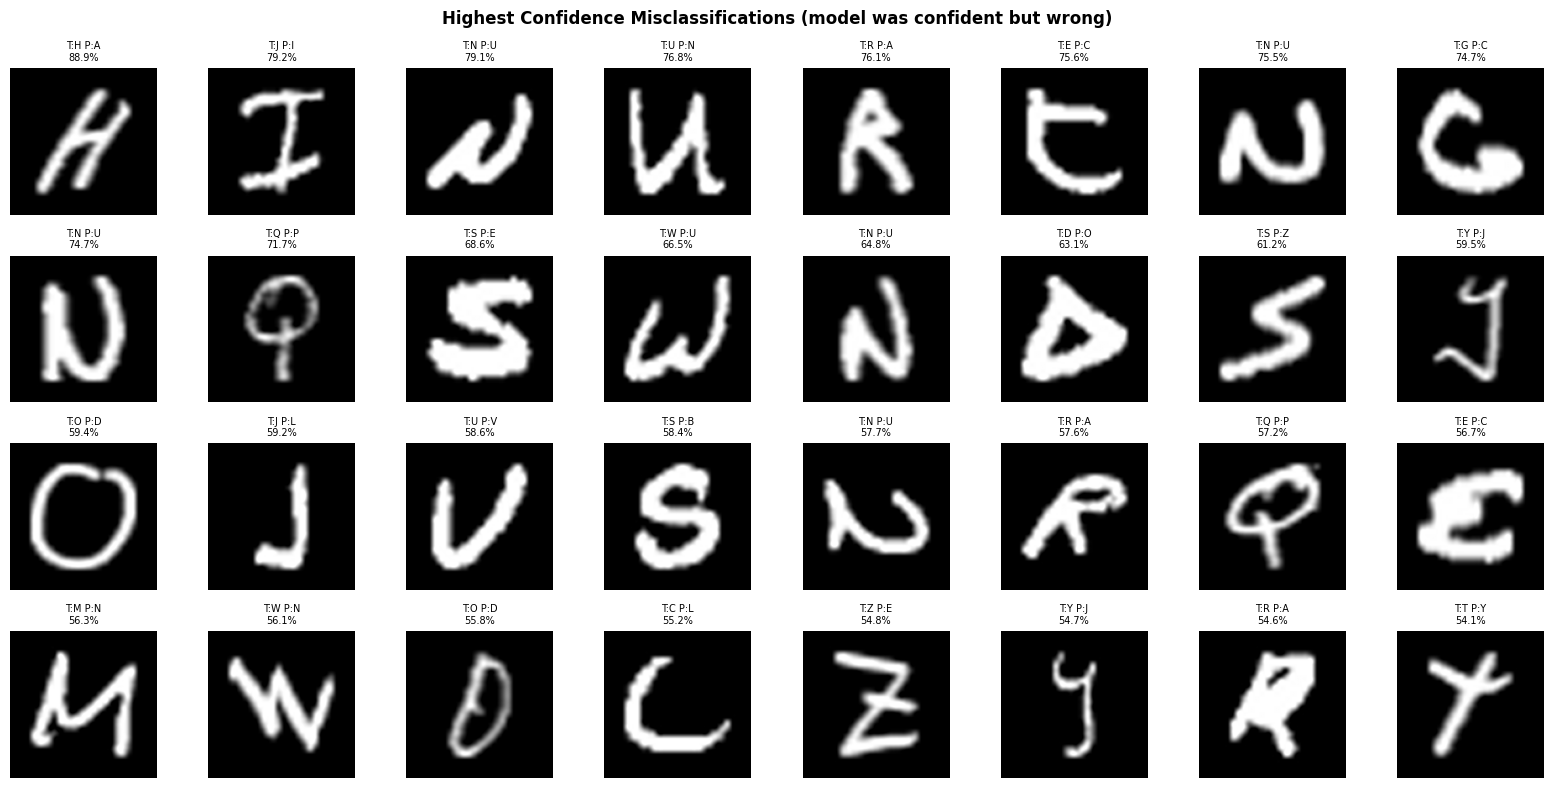

✓ high_conf_errors.png saved


In [28]:
# ─── Collect all misclassified samples (with confidence) ─────────────────────
model.eval()
mis_imgs, mis_true, mis_pred, mis_conf = [], [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='  Collecting misclassifications'):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        confs  = probs.max(dim=1).values

        wrong = preds != labels.to(device)
        if wrong.sum() == 0:
            continue
        mis_imgs.extend(imgs[wrong].cpu())
        mis_true.extend(labels[wrong].numpy())
        mis_pred.extend(preds[wrong].cpu().numpy())
        mis_conf.extend(confs[wrong].cpu().numpy())

print(f"  Total misclassifications : {len(mis_imgs):,}")

# ─── Helper to visualise a 2-row grid ────────────────────────────────────────
def plot_pair_grid(pair_imgs, pair_true, pair_pred, pair_conf,
                   true_c, pred_c, fname, max_per_row=8):
    n   = min(len(pair_imgs), max_per_row)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    if n == 1:
        axes = [axes]
    for ax, img_t, tr, pr, cf in zip(axes,
                                      pair_imgs[:n],
                                      pair_true[:n],
                                      pair_pred[:n],
                                      pair_conf[:n]):
        ax.imshow(denormalise(img_t).mean(axis=2), cmap='gray')
        ax.set_title(f'T:{CONFIG["classes"][tr]}→P:{CONFIG["classes"][pr]}\n{cf*100:.1f}%', fontsize=7)
        ax.axis('off')
    fig.suptitle(f'Confused: {CONFIG["classes"][true_c]} → {CONFIG["classes"][pred_c]}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.close()

# ─── Top-5 confused pairs (symmetric grids) ──────────────────────────────────
top5_pairs = [(CONFIG['classes'].index(t), CONFIG['classes'].index(p))
              for t, p, _, _ in top_confused_pairs[:5]]

for true_c, pred_c in top5_pairs:
    # true→pred direction
    tp_idx = [i for i, (t, p) in enumerate(zip(mis_true, mis_pred))
              if t == true_c and p == pred_c]
    # pred→true direction
    pt_idx = [i for i, (t, p) in enumerate(zip(mis_true, mis_pred))
              if t == pred_c and p == true_c]

    tc, pc = CONFIG['classes'][true_c], CONFIG['classes'][pred_c]
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    fig.suptitle(f'Confused Pair: {tc} ↔ {pc}', fontsize=13, fontweight='bold')

    for row, idx_list, true_c_, pred_c_ in [(0, tp_idx, true_c, pred_c),
                                             (1, pt_idx, pred_c, true_c)]:
        for col in range(8):
            ax = axes[row, col]
            if col < len(idx_list):
                i = idx_list[col]
                ax.imshow(denormalise(mis_imgs[i]).mean(axis=2), cmap='gray')
                ax.set_title(f'{mis_conf[i]*100:.1f}%', fontsize=8)
            ax.axis('off')
        axes[row, 0].set_ylabel(
            f'T:{CONFIG["classes"][true_c_]}→P:{CONFIG["classes"][pred_c_]}',
            fontsize=9, rotation=90, labelpad=5
        )

    plt.tight_layout()
    fname = f'misclassified_{tc}_{pc}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"  ✓ {fname} saved")

# ─── 32 highest-confidence misclassifications ────────────────────────────────
sorted_conf_idx = np.argsort(mis_conf)[::-1][:32]
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Highest Confidence Misclassifications (model was confident but wrong)',
             fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(sorted_conf_idx):
        idx = sorted_conf_idx[i]
        ax.imshow(denormalise(mis_imgs[idx]).mean(axis=2), cmap='gray')
        tc = CONFIG['classes'][mis_true[idx]]
        pc = CONFIG['classes'][mis_pred[idx]]
        ax.set_title(f'T:{tc} P:{pc}\n{mis_conf[idx]*100:.1f}%', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('high_conf_errors.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ high_conf_errors.png saved")


**Observation:** High-confidence errors are the most diagnostic — they reveal systematic failure modes in the feature representation, not just random noise.

## Step 14 — Model Checkpoint Summary
Print checkpoint metadata and save a human-readable `model_card.json` for deployment documentation.

In [30]:
# ─── Print checkpoint metadata ───────────────────────────────────────────────
print(f"  Checkpoint path   : {CONFIG['checkpoint_path']}")
print(f"  Saved at epoch    : {checkpoint['epoch']}")
print(f"  Best val accuracy : {checkpoint['val_acc']*100:.4f}%")
print(f"  Config snapshot   :")
for k, v in checkpoint['config'].items():
    if k not in ('imagenet_mean', 'imagenet_std', 'classes'):
        print(f"    {k:<22}: {v}")

# ─── Model card ───────────────────────────────────────────────────────────────
total_params_n     = sum(p.numel() for p in model.parameters())
trainable_params_n = sum(p.numel() for p in model.parameters() if p.requires_grad)

model_card = {
    "model"            : "MobileNetV2 fine-tuned",
    "task"             : "A-Z Handwritten Character Recognition",
    "num_classes"      : CONFIG['num_classes'],
    "input_size"       : "224x224x3",
    "test_accuracy"    : round(float(overall_acc), 4),
    "macro_f1"         : round(float(macro_f1), 4),
    "best_epoch"       : int(checkpoint['epoch']),
    "total_params"     : total_params_n,
    "trainable_params" : trainable_params_n,
    "training_samples" : len(train_df),
    "val_samples"      : len(val_df),
    "test_samples"     : len(test_df),
    "freeze_strategy"  : f"head-only for {CONFIG['freeze_epochs']} epochs, then full fine-tune",
    "optimizer"        : "Adam",
    "loss"             : "CrossEntropyLoss with class weights",
    "checkpoint_file"  : CONFIG['checkpoint_path']
}

with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("\n  Model Card:")
print(json.dumps(model_card, indent=2))
print("\n✓ model_card.json saved")


  Checkpoint path   : ocr_mobilenetv2.pth
  Saved at epoch    : 15
  Best val accuracy : 91.9614%
  Config snapshot   :
    train_path            : train_augmented.csv
    val_path              : val.csv
    test_path             : test.csv
    img_size              : 224
    batch_size            : 32
    num_classes           : 26
    num_epochs            : 15
    learning_rate         : 0.0001
    weight_decay          : 0.0001
    patience              : 5
    dropout_rate          : 0.3
    freeze_epochs         : 5
    unfreeze_epoch        : 6
    fine_tune_lr          : 1e-05
    checkpoint_path       : ocr_mobilenetv2.pth
    log_path              : training_log.csv
    random_state          : 42
    device                : cpu

  Model Card:
{
  "model": "MobileNetV2 fine-tuned",
  "task": "A-Z Handwritten Character Recognition",
  "num_classes": 26,
  "input_size": "224x224x3",
  "test_accuracy": 0.9225,
  "macro_f1": 0.9247,
  "best_epoch": 15,
  "total_params": 4174082,
 

**Observation:** The model card stores all reproducibility metadata in a single JSON — essential for MLOps, auditing, and deployment handoffs.

## Step 15 — Final Summary Report
A clean boxed report covering every aspect of the training run, evaluation results, and output artefacts.

---
## Pipeline Summary

| Step | Description | Output |
|------|-------------|--------|
| 1 | Environment & Config | CONFIG dict, seeds |
| 2 | Dataset & DataLoaders | HandwritingDataset, 3 loaders |
| 3 | Sanity Check & Visualisation | sample_grid.png, class_distribution.png |
| 4 | Model Architecture | OCRMobileNetV2 |
| 5 | Loss / Optimizer / Scheduler | Weighted CE, Adam, ReduceLROnPlateau |
| 6 | Training Loop | ocr_mobilenetv2.pth, training_log.csv |
| 7 | Training Curves | training_curves.png |
| 8 | Test Set Evaluation | Overall accuracy |
| 9 | Confusion Matrix | confusion_matrix.png, confusion_matrix_normalised.png |
| 10 | F1 Analysis | per_class_f1.png |
| 11 | Per-Class Accuracy | per_class_accuracy.png |
| 12 | Misclassification Grids | misclassified_*.png, high_conf_errors.png |
| 13 | Grad-CAM | gradcam_analysis.png |
| 14 | Checkpoint Summary | model_card.json |
| 15 | Final Report | Printed summary |
